In [ ]:
# imports
from os import system,path,listdir
from pathlib import Path
from collections import Counter
from matplotlib import pyplot as plt
from pandas import DataFrame
from numpy import arange
from math import sqrt

In [29]:
# variables
graph_paths:list[str] = [x for x in listdir('.') if x.endswith('.gfa')]
graph_ids:list[str] = [Path(x).stem for x in graph_paths]

In [30]:
# on télécharge l'executable
if not path.exists('./rs-pancat-paths'):
    system("wget https://github.com/dubssieg/rs-pancat-paths/releases/download/0.1.3/rs-pancat-paths")
    system("chmod +x rs-pancat-paths")

In [31]:
for i,x in enumerate(graph_paths):
# calcul des nœuds ancres
    if not path.exists(f"anchors_{graph_ids[i]}.tsv"):
        system(f"./rs-pancat-paths {x} anchors -a 15 > anchors_{graph_ids[i]}.tsv")

In [ ]:
# visualisation des nœuds ancres
anchors:list[Counter] = [Counter() for _ in graph_ids]
for i,x in enumerate(graph_paths):
    with open(f"anchors_{graph_ids[i]}.tsv") as tsvreader:
        for line in tsvreader:
            if line.startswith('#'):
                continue
            else:
                k:int=int(line.strip().split('\t')[1])
                anchors[i][k] = anchors[i].get(k, 0) + 1

In [35]:
print("Nom\tµ\tσ")
for i,ctr in enumerate(anchors):
    sum_of_numbers = sum(number*count for number, count in ctr.items())
    count = sum(count for n, count in ctr.items())
    mu = sum_of_numbers / count
    total_squares = sum(number*number * count for number, count in ctr.items())
    mean_of_squares = total_squares / count
    variance = mean_of_squares - mu * mu
    std_dev = sqrt(variance)
    print(f"{graph_ids[i]}\t{mu}\t{std_dev}")

Nom	µ	σ
MC	6.348992519132104	4.878502238307354
PGGB	7.289457244699225	5.186171135463996


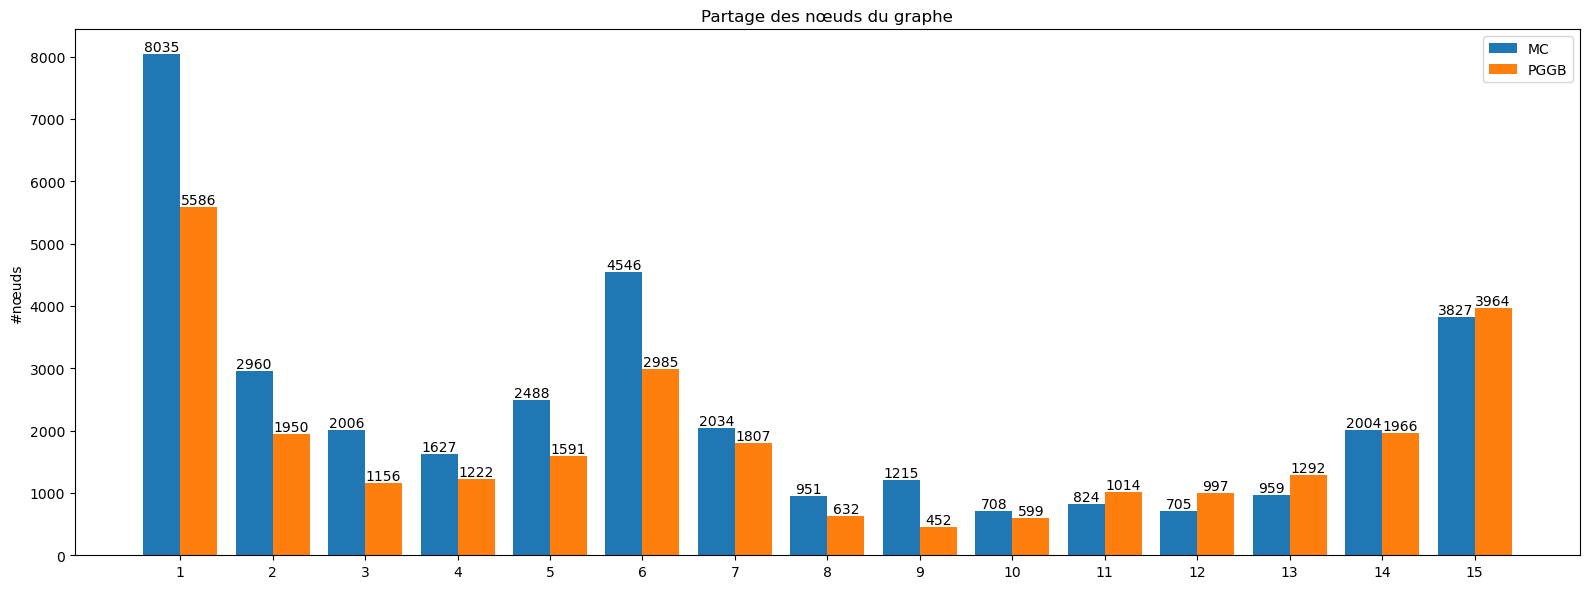

In [ ]:
#x-axis
x_axis = list(range(1,16))
#y-axis
bars_values = [[anchors[i][n] for n in x_axis] for i in range(len(graph_ids))]

#bar chart properties
x = arange(len(x_axis))
width = 1/len(bars_values) - 0.1

#draw grouped bar chart
fig, ax = plt.subplots(figsize=(16,6))
for i,data in enumerate(bars_values):
    barx = ax.bar(x + width*i, data, width, label=graph_ids[i])
    ax.bar_label(barx)


ax.set_ylabel('#nœuds')
ax.set_title('Partage des nœuds du graphe')
ax.set_xticks((x+width*(len(graph_ids)/2)-width/2), x_axis)
ax.legend()

fig.tight_layout()
plt.show()